In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator, PercentFormatter
from matplotlib.patches import Patch

from tokengt_paper_repo.pcqm4mv2_pyg import PygPCQM4Mv2Dataset
from torch_geometric.loader import DataLoader

from tokengt_experiments.motif_selection.zinc_smiles_dataset import ZincSmilesDataset
from rdkit import Chem
from rdkit.Chem import BRICS

import torch
import random

warnings.filterwarnings('ignore')

# Suppress RDKit warnings
import rdkit
lg = rdkit.RDLogger.logger()
lg.setLevel(rdkit.RDLogger.CRITICAL)



ModuleNotFoundError: No module named 'tokengt_experiments.motif_selection'

In [18]:

mol = Chem.MolFromSmiles("CC(=O)OC1=CC=CC=C1C(=O)O")  # aspirin
frags = BRICS.BRICSDecompose(mol)                     # returns a set of fragment SMILES with * attachment points
print(frags)

# Break the molecule at BRICS bonds:
mol_broken = BRICS.BreakBRICSBonds(mol)

# Split into disconnected fragments:
parts = Chem.GetMolFrags(mol_broken, asMols=True, sanitizeFrags=True)

def remove_dummy_atoms(mol):
    em = Chem.EditableMol(mol)
    dummy_atoms = [a.GetIdx() for a in mol.GetAtoms() if a.GetAtomicNum() == 0]
    for idx in reversed(dummy_atoms):  # delete in reverse order to keep indices valid
        em.RemoveAtom(idx)
    return em.GetMol()

frag_smiles = [Chem.MolToSmiles(remove_dummy_atoms(p), canonical=True) for p in parts]
print(frag_smiles)

{'[16*]c1ccccc1[16*]', '[6*]C(=O)O', '[1*]C(C)=O', '[3*]O[3*]'}
['CC=O', 'O', 'c1ccccc1', 'O=CO']


In [26]:
num_molecules = 10000
min_motif_size = 2
min_motif_frequency = 0.1

dataset = ZincSmilesDataset(root="data/zinc/", split="train", subset=True)
indices = random.sample(range(len(dataset)), num_molecules)
mol_smiles = [dataset[i].smiles for i in indices]
molecules = [Chem.MolFromSmiles(smiles) for smiles in mol_smiles]

In [20]:
all_smiles = set()

for mol in tqdm(molecules):
    mol_broken = BRICS.BreakBRICSBonds(mol)
    parts = Chem.GetMolFrags(mol_broken, asMols=True, sanitizeFrags=True)
    frag_smiles = [Chem.MolToSmiles(remove_dummy_atoms(p), canonical=True) for p in parts]
    all_smiles.update(frag_smiles)

len(all_smiles)


100%|██████████| 10000/10000 [01:03<00:00, 157.26it/s]


4127

In [21]:
motif_smiles = list(all_smiles)
motifs = [Chem.MolFromSmiles(smiles) for smiles in motif_smiles if Chem.MolFromSmiles(smiles) is not None]
motif_smiles = [smiles for smiles in motif_smiles if Chem.MolFromSmiles(smiles) is not None]
[molecules[i].GetSubstructMatches(motifs[1]) for i in range(len(molecules))]
len(molecules), len(motifs), len(motif_smiles)

(10000, 3807, 3807)

In [22]:
def find_motif_matches(molecules, motif_mols, motif_smiles):
    results = defaultdict(list)

    for mol_idx, mol in enumerate(tqdm(molecules, desc="Processing molecules")):
        for motif_idx, motif_mol in enumerate(motif_mols):
            matches = mol.GetSubstructMatches(motif_mol)
            
            if matches:
                results[motif_smiles[motif_idx]].append({
                    'molecule_idx': mol_idx,
                    'num_matches': len(matches),
                    'match_positions': matches
                })
    
    return results


def analyze_motif_frequency(match_results, num_molecules):
    motif_stats = {}
    
    for motif_smiles, matches in match_results.items():
        molecules_with_motif = len(set(match['molecule_idx'] for match in matches))
        total_matches = sum(match['num_matches'] for match in matches)
        motif_stats[motif_smiles] = {
            'frequency': molecules_with_motif / num_molecules,
            'total_matches': total_matches,
            'avg_matches_per_mol': total_matches / molecules_with_motif if molecules_with_motif > 0 else 0,
            'molecules_with_motif': molecules_with_motif
        }
    
    return motif_stats


In [8]:

match_results = find_motif_matches(molecules, motifs, motif_smiles)
motif_stats = analyze_motif_frequency(match_results, len(molecules))
motif_stats

Processing molecules: 100%|██████████| 10000/10000 [03:45<00:00, 44.43it/s]


{'Clc1ccccc1': {'frequency': 0.116,
  'total_matches': 1341,
  'avg_matches_per_mol': 1.1560344827586206,
  'molecules_with_motif': 1160},
 'S': {'frequency': 0.3501,
  'total_matches': 4100,
  'avg_matches_per_mol': 1.1710939731505283,
  'molecules_with_motif': 3501},
 'C/C(Cl)=C/Cl': {'frequency': 0.0001,
  'total_matches': 1,
  'avg_matches_per_mol': 1.0,
  'molecules_with_motif': 1},
 'CCl': {'frequency': 0.144,
  'total_matches': 1682,
  'avg_matches_per_mol': 1.1680555555555556,
  'molecules_with_motif': 1440},
 'CN': {'frequency': 0.9444,
  'total_matches': 39008,
  'avg_matches_per_mol': 4.130453197797544,
  'molecules_with_motif': 9444},
 'N': {'frequency': 0.9767,
  'total_matches': 28349,
  'avg_matches_per_mol': 2.902528923927511,
  'molecules_with_motif': 9767},
 'Nc1ccc(Cl)cc1': {'frequency': 0.0154,
  'total_matches': 154,
  'avg_matches_per_mol': 1.0,
  'molecules_with_motif': 154},
 'C': {'frequency': 1.0,
  'total_matches': 170895,
  'avg_matches_per_mol': 17.0895,
  

In [31]:
motif_stats_smaller = {k: v for k, v in motif_stats.items() if v['frequency'] > min_motif_frequency}
print(f"Number of motifs with frequency > {min_motif_frequency}: {len(motif_stats_smaller)}")
motif_stats_smaller = {k: v for k, v in motif_stats_smaller.items() if Chem.MolFromSmiles(k).GetNumAtoms() >= min_motif_size}
print(f"Number of motifs with frequency > {min_motif_frequency} and num atoms >= {min_motif_size}: {len(motif_stats_smaller)}")
motif_stats_smaller

Number of motifs with frequency > 0.1: 66
Number of motifs with frequency > 0.1 and num atoms >= 2: 62


{'Clc1ccccc1': {'frequency': 0.116,
  'total_matches': 1341,
  'avg_matches_per_mol': 1.1560344827586206,
  'molecules_with_motif': 1160,
  'smiles': 'Clc1ccccc1'},
 'CCl': {'frequency': 0.144,
  'total_matches': 1682,
  'avg_matches_per_mol': 1.1680555555555556,
  'molecules_with_motif': 1440,
  'smiles': 'CCl'},
 'CN': {'frequency': 0.9444,
  'total_matches': 39008,
  'avg_matches_per_mol': 4.130453197797544,
  'molecules_with_motif': 9444,
  'smiles': 'CN'},
 'Nc1ccccc1': {'frequency': 0.3248,
  'total_matches': 3951,
  'avg_matches_per_mol': 1.2164408866995073,
  'molecules_with_motif': 3248,
  'smiles': 'Nc1ccccc1'},
 'CCS': {'frequency': 0.1407,
  'total_matches': 2459,
  'avg_matches_per_mol': 1.747690120824449,
  'molecules_with_motif': 1407,
  'smiles': 'CCS'},
 'CS': {'frequency': 0.223,
  'total_matches': 3948,
  'avg_matches_per_mol': 1.770403587443946,
  'molecules_with_motif': 2230,
  'smiles': 'CS'},
 'c1ccccc1': {'frequency': 0.77,
  'total_matches': 10682,
  'avg_match

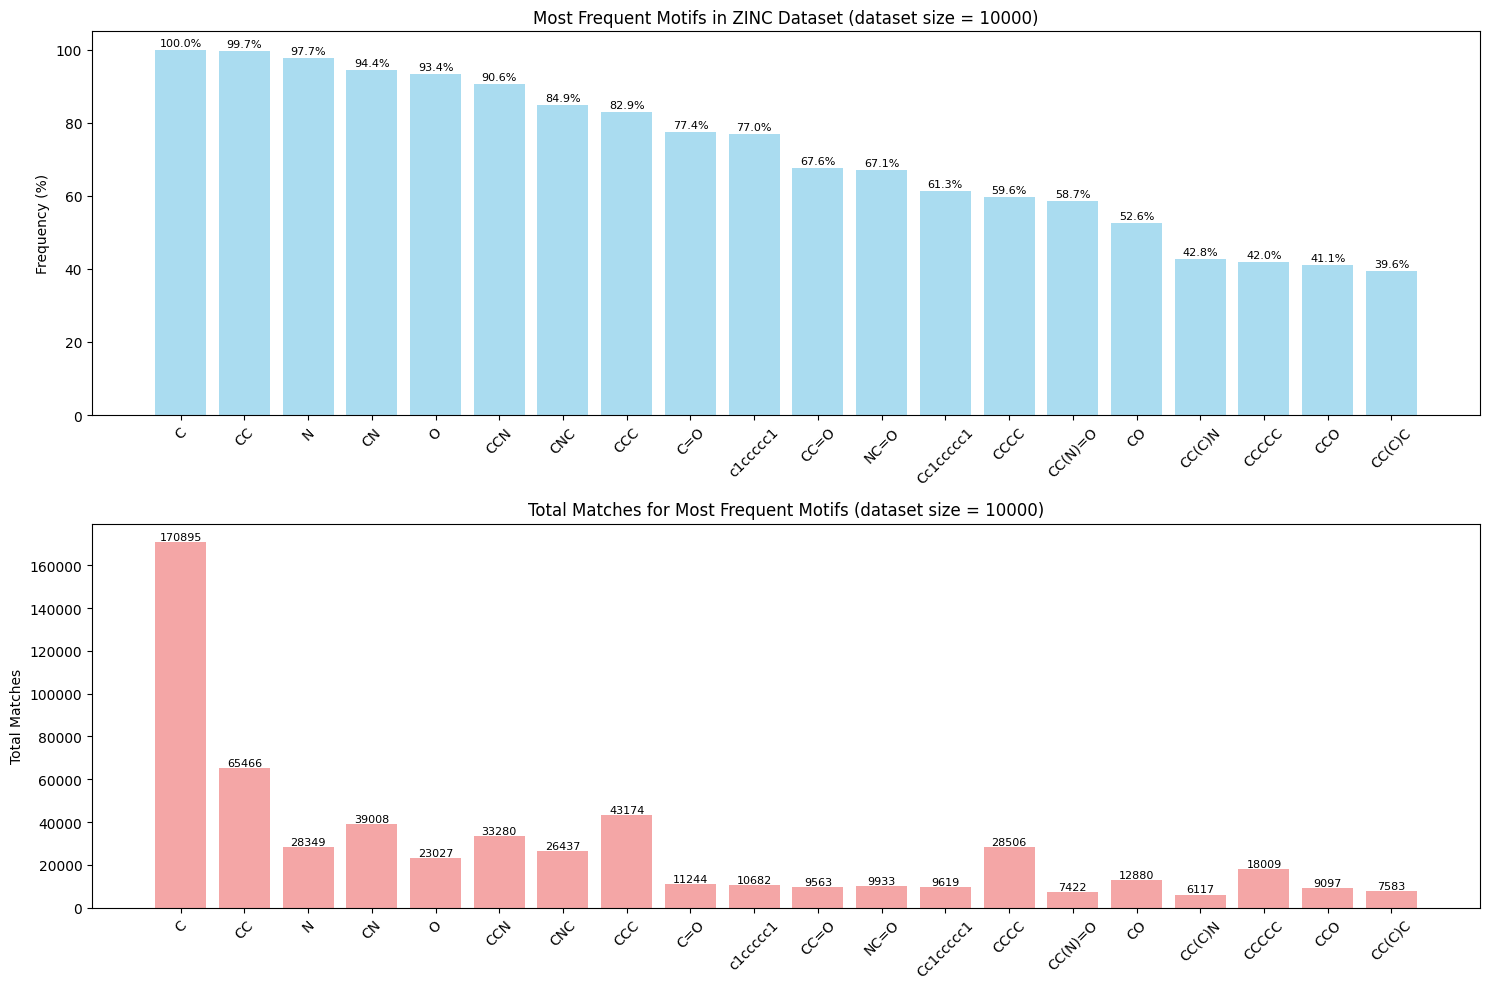

In [23]:
def visualize_motif_frequency(motif_stats, top_n=20):
    for key in motif_stats.keys():
        motif_stats[key]["smiles"] = key
    
    sorted_motifs = sorted(motif_stats.items(), 
                          key=lambda x: x[1]['frequency'], 
                          reverse=True)[:top_n]
    
    motifs = [item[0] for item in sorted_motifs]
    frequencies = [item[1]['frequency'] * 100 for item in sorted_motifs]
    
    plt.figure(figsize=(15, 10))
    
    # Create subplot for frequency
    plt.subplot(2, 1, 1)
    bars = plt.bar(range(len(motifs)), frequencies, color='skyblue', alpha=0.7)
    plt.ylabel('Frequency (%)')
    plt.title(f'Most Frequent Motifs in ZINC Dataset (dataset size = {num_molecules})')
    plt.xticks(range(len(motifs)), [motif_stats[motif]['smiles'] for motif in motifs], rotation=45)
    
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{frequencies[i]:.1f}%', ha='center', va='bottom', fontsize=8)
    
    # Create subplot for total matches
    total_matches = [item[1]['total_matches'] for item in sorted_motifs]
    plt.subplot(2, 1, 2)
    bars2 = plt.bar(range(len(motifs)), total_matches, color='lightcoral', alpha=0.7)
    plt.ylabel('Total Matches')
    plt.title(f'Total Matches for Most Frequent Motifs (dataset size = {num_molecules})')
    plt.xticks(range(len(motifs)), [motif_stats[motif]['smiles'] for motif in motifs], rotation=45)
    
    for i, bar in enumerate(bars2):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{total_matches[i]}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
visualize_motif_frequency(motif_stats_smaller, top_n=20)

In [32]:
num_matches = [motif_stats_smaller[key]["total_matches"] for key in motif_stats_smaller.keys()]
print(f"Total number of matches: {sum(num_matches)}")

Total number of matches: 514466


In [34]:
list(motif_stats_smaller.keys()) 

['Clc1ccccc1',
 'CCl',
 'CN',
 'Nc1ccccc1',
 'CCS',
 'CS',
 'c1ccccc1',
 'CC',
 'NC=O',
 'CC(C)N',
 'Oc1ccccc1',
 'CNC',
 'CCC',
 'CCCC',
 'C=O',
 'CCN',
 'CC=O',
 'Cc1ccccc1',
 'O=Cc1ccccc1',
 'CO',
 'CCc1ccccc1',
 'C[NH3+]',
 'CC(N)=O',
 'Fc1ccccc1',
 'CC(C)C',
 'c1ccncc1',
 'C[SH](=O)=O',
 'CCCO',
 'CCO',
 'CCC=O',
 'CCC(N)=O',
 'CCCCC',
 'CN1CCCCC1',
 'CCCCC=O',
 'CCC(C)C',
 'CCCC=O',
 'CC[C@H](C)C=O',
 'CC[C@@H](C)C=O',
 'C1CCCNC1',
 'C1CCNCC1',
 'CCC(C)CN',
 'CC(C)C=O',
 'NCC=O',
 'CC(C)O',
 'CCC[NH3+]',
 'CC[NH3+]',
 'CCCCCC',
 'CCCC(C)C',
 'CC[C@H](C)CC',
 'CCC[C@H](C)CC',
 'CCCCCCC',
 'CCCCCO',
 'CCC(C)CC',
 'CCCCO',
 'CCC[C@@H](C)CC',
 'CCCC[NH3+]',
 'CCCCC[NH3+]',
 'CC(C)[NH3+]',
 'CCC(C)O',
 'CC[C@H](C)O',
 'CC[C@@H](C)O',
 'C[C@H](C)[NH3+]']

In [28]:
# ZINC

manually_cleaned_motifs = [
    'C=O',
    'NC=O',
    'C1=CC=CC=C1',
    'NCCO',
    'OC1=CC=CC=C1',
    'NC1=CC=CC=C1',
    'COC',
    'C1=CC=NC=C1',
    'NCN',
    'O=S',
    'CN1CCCCC1',
    'C1CCNCC1',
    'O=CO']

In [29]:
manually_cleaned_stats = {k: v for k, v in motif_stats.items() if k in manually_cleaned_motifs}
manually_cleaned_stats

{'NC=O': {'frequency': 0.6713,
  'total_matches': 9933,
  'avg_matches_per_mol': 1.4796663190823776,
  'molecules_with_motif': 6713,
  'smiles': 'NC=O'},
 'C=O': {'frequency': 0.774,
  'total_matches': 11244,
  'avg_matches_per_mol': 1.4527131782945737,
  'molecules_with_motif': 7740,
  'smiles': 'C=O'},
 'CN1CCCCC1': {'frequency': 0.12,
  'total_matches': 1277,
  'avg_matches_per_mol': 1.0641666666666667,
  'molecules_with_motif': 1200,
  'smiles': 'CN1CCCCC1'},
 'C1CCNCC1': {'frequency': 0.1381,
  'total_matches': 1462,
  'avg_matches_per_mol': 1.0586531498913831,
  'molecules_with_motif': 1381,
  'smiles': 'C1CCNCC1'}}

In [53]:
num_matches = [manually_cleaned_stats[key]["total_matches"] for key in manually_cleaned_stats.keys()]
print(f"Total number of matches: {sum(num_matches)}")

Total number of matches: 5735


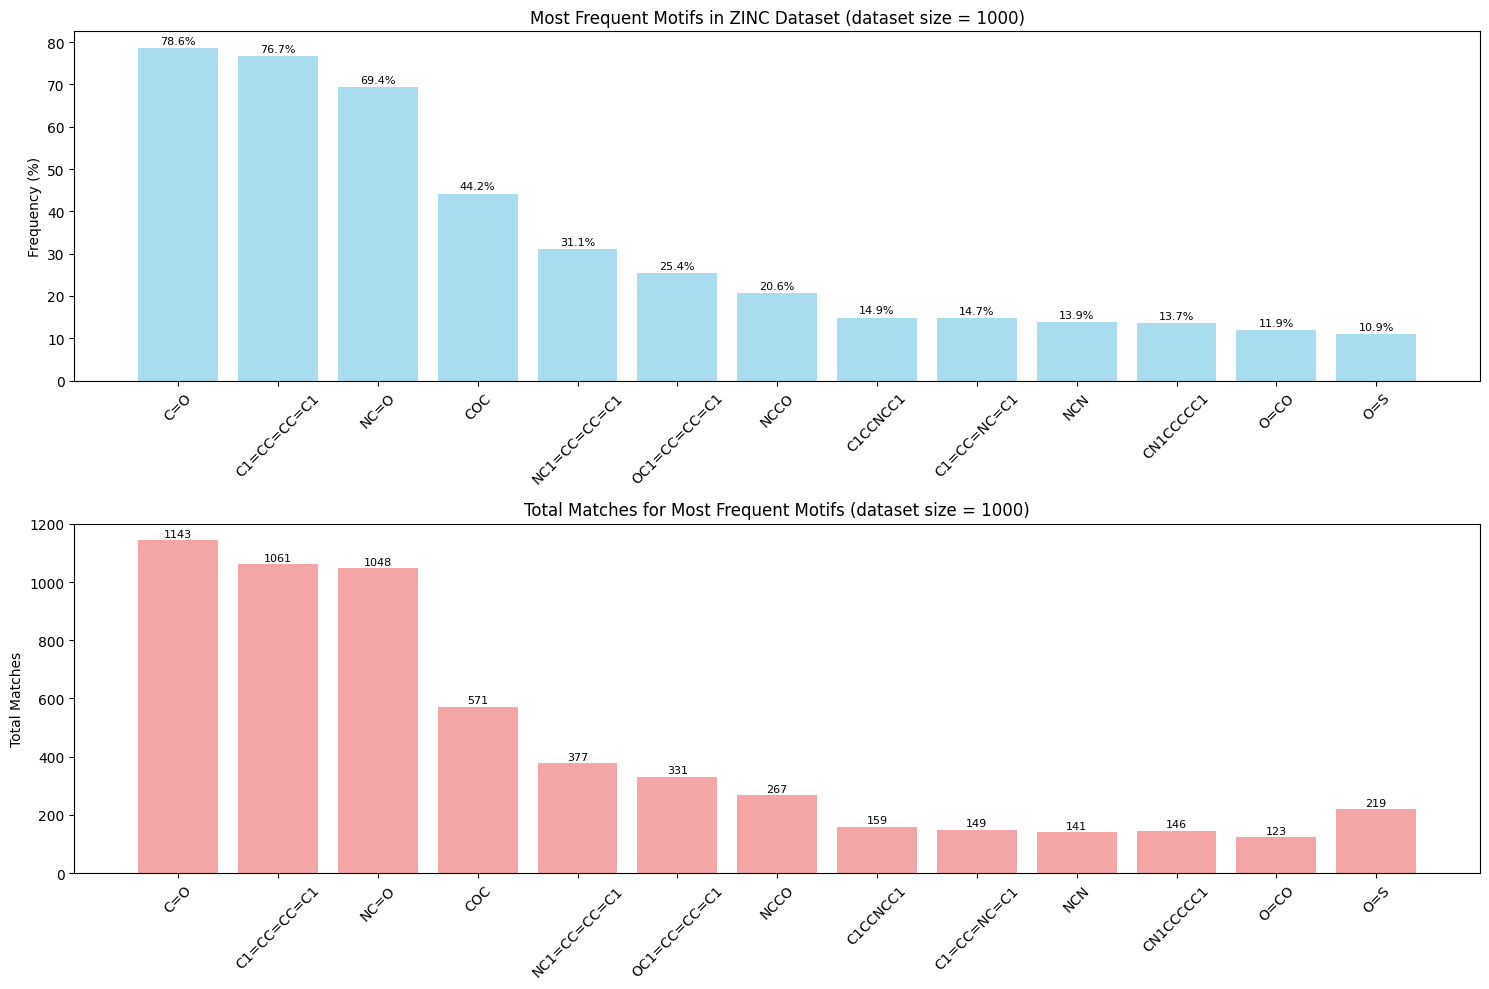

In [38]:
visualize_motif_frequency(manually_cleaned_stats, top_n=20)

In [25]:
num_matches = [manually_cleaned_stats[key]["total_matches"] for key in manually_cleaned_stats.keys()]
print(f"Total number of matches: {sum(num_matches)}")
print(f"Total number of motifs: {len(manually_cleaned_stats)}")

Total number of matches: 2469
Total number of motifs: 10


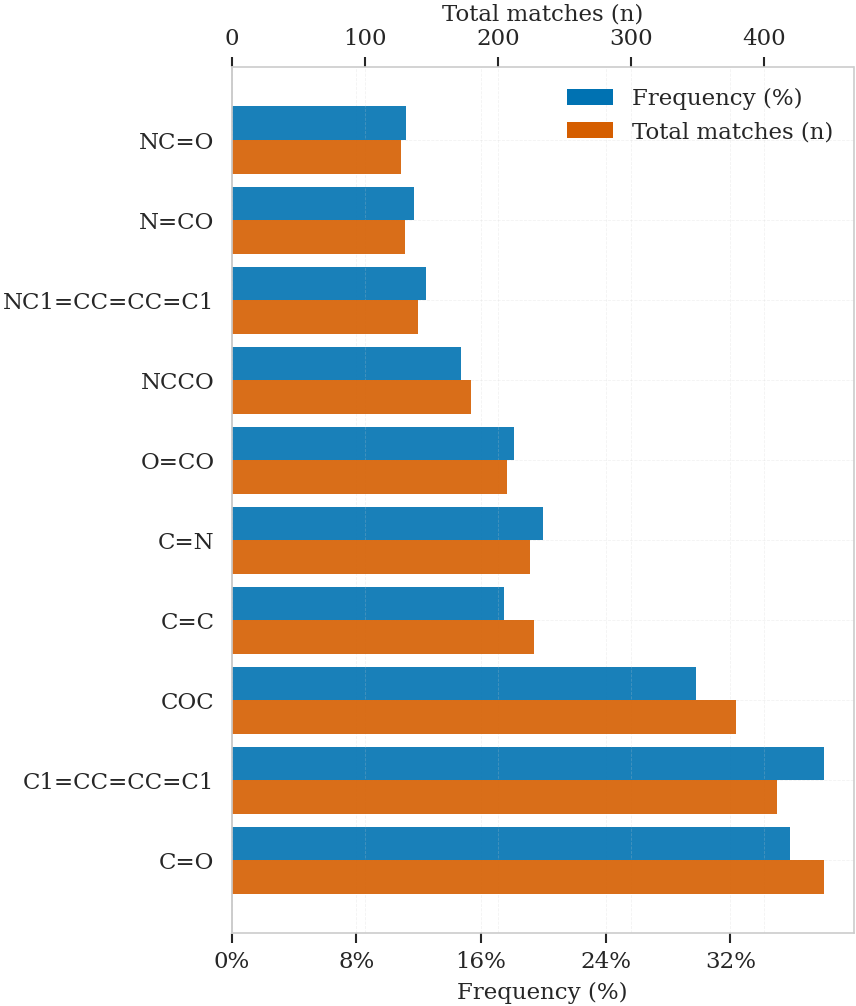

In [74]:
def plot_motif_dualbars(
    motif_stats,
    num_molecules,
    top_n=20,
):
    fig_width_in=6.0
    height_per_bar_in=0.32
    outfile="motifs_dualbars.pdf"
    palette=("#0072B2", "#D55E00")

    figure_height = max(1.6, height_per_bar_in * max(3, top_n) + 0.6)
    with mpl.rc_context({
        "figure.figsize": (fig_width_in, figure_height),
        "figure.dpi": 150,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        "font.size": 11,
        "axes.titlesize": 11,
        "axes.labelsize": 11,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "font.family": "serif",
        "axes.linewidth": 0.8,
        "grid.linewidth": 0.4,
        "grid.alpha": 0.25,
        "grid.linestyle": "--",
        "legend.frameon": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }):
        rows = []
        for k, v in motif_stats.items():
            f = float(v["frequency"])
            pct = 100.0 * f
            n = v["total_matches"]
            rows.append((k, pct, n))

        rows.sort(key=lambda t: t[2], reverse=True)
        rows = rows[:top_n]

        motifs = [r[0] for r in rows][::-1]
        freq_pct = np.array([r[1] for r in rows], dtype=float)[::-1]
        counts = np.array([r[2] for r in rows], dtype=int)[::-1]

        y_labels = motifs

        freq_color, count_color = palette
        fig, ax_pct = plt.subplots()

        y = np.arange(len(motifs))
        bar_h = 0.42  # group height ~0.84

        b1 = ax_pct.barh(
            y - bar_h/2, freq_pct, height=bar_h, label="Frequency (%)",
            color=freq_color, alpha=0.9, edgecolor="none", zorder=3
        )
        ax_pct.set_xlabel("Frequency (%)")
        ax_pct.set_yticks(y)
        ax_pct.set_yticklabels(y_labels)
        ax_pct.invert_yaxis()
        ax_pct.xaxis.set_major_locator(MaxNLocator(5))
        ax_pct.xaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
        ax_pct.grid(axis="x", zorder=0)

        ax_cnt = ax_pct.twiny()
        b2 = ax_cnt.barh(
            y + bar_h/2, counts, height=bar_h, label="Total matches (n)",
            color=count_color, alpha=0.9, edgecolor="none", zorder=2
        )
        ax_cnt.set_xlabel("Total matches (n)")
        ax_cnt.xaxis.set_major_locator(MaxNLocator(5, integer=True))
        ax_cnt.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))

        legend_handles = [
            Patch(facecolor=freq_color, edgecolor="none", label="Frequency (%)"),
            Patch(facecolor=count_color, edgecolor="none", label="Total matches (n)"),
        ]
        ax_pct.legend(handles=legend_handles, loc="upper right")

        # ax_pct.set_title(f"The {len(motifs)} most frequent motifs in first {num_molecules:,} molecules of PCQM4Mv2")

        for spine in ["top", "right"]:
            ax_pct.spines[spine].set_visible(False)
        ax_cnt.spines["bottom"].set_visible(False)  # avoid double baseline

        fig.tight_layout()
        fig.savefig(outfile)
        return fig, (ax_pct, ax_cnt)

fig, ax = plot_motif_dualbars(manually_cleaned_stats, num_molecules=num_molecules, top_n=20)

